In [2]:
%pip install pandas numpy scikit-learn

import pandas as pd
import numpy as np
import sklearn
print(f"Pandas version: {pd.__version__}")

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Pandas version: 3.0.2


In [40]:
from avgEmoValues import get_vals
import os
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

lex_df = pd.read_table(os.path.join("lexicons", "NRC_EmoLex_NRC-VAD-Lexicon.txt"), header=None, names=["word","val","aro","dom"])
if 'word' in lex_df.columns:
    lex_df = lex_df.set_index('word')
lex_df.head()

books = ["AlicesAdventuresInWonderland", "APassageToIndia", "DaisyMiller", "Emma", "HardTimes", "NightAndDay", "OliverTwist", "NorthangerAbbey", "Persuasion", "PrideAndPrejudice", "SenseAndSensibility", "TheGambler", "TheInvisibleMan", "TheMysteriousAffairAtStyles", "ThePictureOfDorianGray", "TheSignOfTheFour", "WhereAngelsFearToTread", "WinnieThePooh"]
for book in books:
    with open(os.path.join("data", book, "novel_text.txt"), "r", encoding="utf-8") as file:
        content = file.read()
        # print(content)
        
all_quotes = {}
for book in books:
    quote_df = pd.read_csv(os.path.join("data", book, "quotation_info.csv"))
    all_quotes[book] = quote_df.groupby("speaker")["quoteText"].apply(list).to_dict()

points = []
character_names = []

# used from paper
def get_vals(twt, lexdf):
    tt = twt.lower().split(" ")
    at = [w for w in tt if w.isalpha()]

    pw = [x for x in tt if x in lexdf.index]
    pv = [lexdf.loc[w]['val'] for w in pw]
    pa = [lexdf.loc[w]['aro'] for w in pw]
    pd = [lexdf.loc[w]['dom'] for w in pw]


    numTokens = len(at)
    numLexTokens = len(pw)
    
    avgLexVal = np.mean(pv)
    avgLexAro = np.mean(pa)
    avgLexDom = np.mean(pd)

    return [numTokens, numLexTokens, avgLexVal, avgLexAro, avgLexDom]

for book, speaker in all_quotes.items():
    for speaker, quote in speaker.items():
        full_text = " ".join(quote)
        stats = get_vals(full_text, lex_df)

        v = np.nan_to_num(stats[2])
        a = np.nan_to_num(stats[3])
        d = np.nan_to_num(stats[4])

        points.append([v, a, d])
        character_names.append(f"{book}: {speaker}")
        
X = np.array(points)
kmeans = KMeans(n_clusters=5, random_state=42)   
clusters = kmeans.fit_predict(X)

/opt/tljh/user/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/tljh/user/lib/python3.12/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


/tmp/ipykernel_847794/3601797546.py:27: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


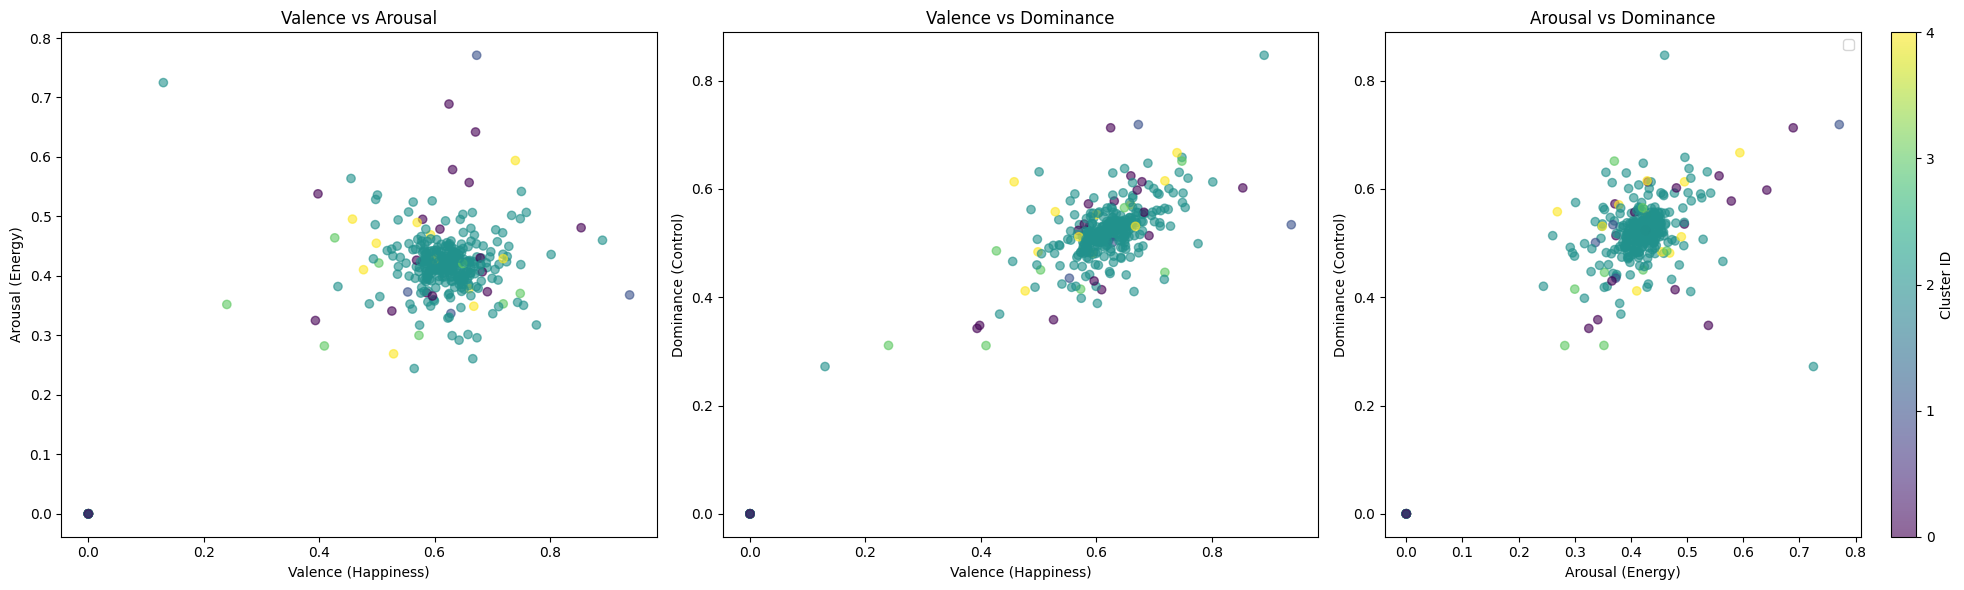

In [63]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 6))

v = X[:, 0]
a = X[:, 1]
d = X[:, 2]

scatter1 = ax1.scatter(v, a, c=clusters, alpha=0.6)
ax1.set_xlabel('Valence (Happiness)')
ax1.set_ylabel('Arousal (Energy)')
ax1.set_title('Valence vs Arousal')

scatter2 = ax2.scatter(v, d, c=clusters, alpha=0.6)
ax2.set_xlabel('Valence (Happiness)')
ax2.set_ylabel('Dominance (Control)')
ax2.set_title('Valence vs Dominance')

scatter3 = ax3.scatter(a, d, c=clusters, alpha=0.6)
ax3.set_xlabel('Arousal (Energy)')
ax3.set_ylabel('Dominance (Control)')
ax3.set_title('Arousal vs Dominance')

cb = fig.colorbar(scatter3, ax=ax3, label='Cluster ID')

cb.set_ticks(np.arange(5))
# fig.colorbar(scatter3, ax=ax3, label='Cluster ID')

plt.legend()

plt.tight_layout()
plt.show()

/opt/tljh/user/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/tljh/user/lib/python3.12/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


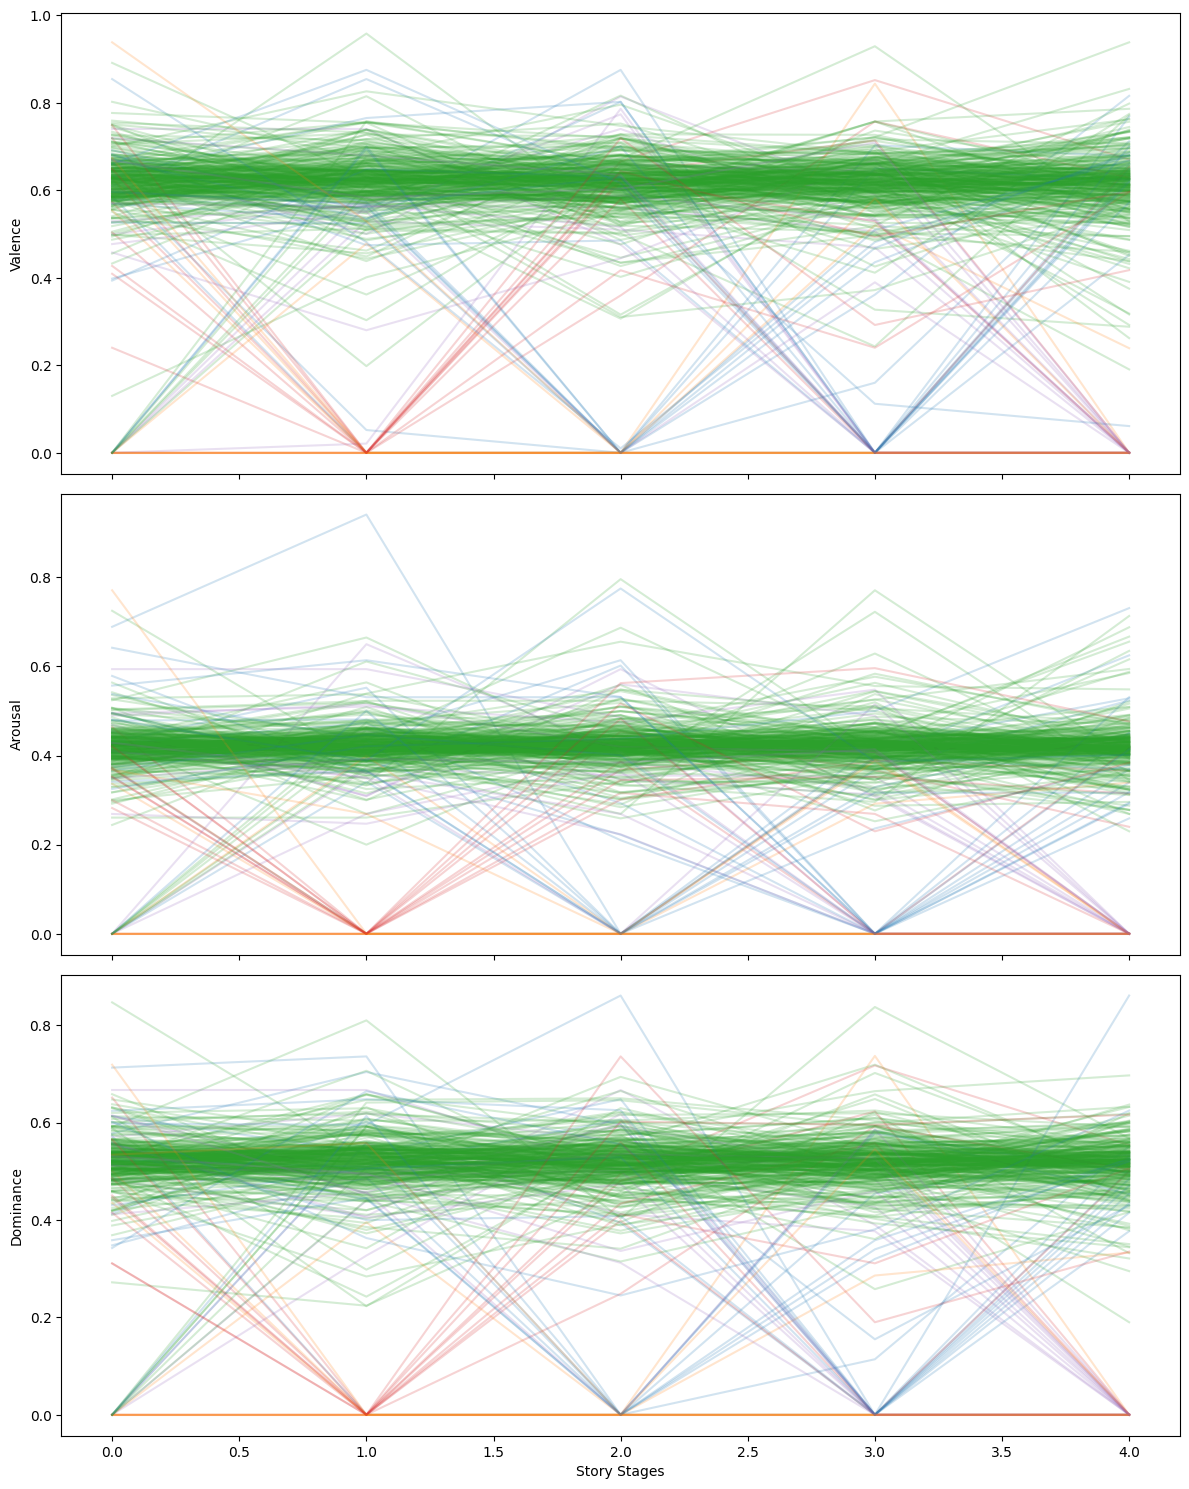

In [62]:
num_stages = 5 
X_features = []
metadata = []   

for book, speakers in all_quotes.items():
    for speaker, quotes in speakers.items():
        
        if len(quotes) < num_stages:
            continue
            
        quote_stages = np.array_split(quotes, num_stages)
        char_arc = []
        
        for stage in quote_stages:
            stage_text = " ".join(stage)
            stats = get_vals(stage_text, lex_df)
            
            v = np.nan_to_num(stats[2])
            a = np.nan_to_num(stats[3])
            d = np.nan_to_num(stats[4])
            char_arc.extend([v, a, d])   
            
        X_features.append(char_arc)
        metadata.append({"book": book, "speaker": speaker})

X = np.array(X_features)

kmeans = KMeans(n_clusters=5, random_state=42)
clusters = kmeans.fit_predict(X)

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 15), sharex=True)

stages = np.arange(num_stages)

for i in range(len(X)):
    v_traj = X[i, 0::3] 
    a_traj = X[i, 1::3] 
    d_traj = X[i, 2::3] 
    
    color = plt.cm.tab10(clusters[i])
    
    ax1.plot(stages, v_traj, alpha=0.2, color=color)
    ax2.plot(stages, a_traj, alpha=0.2, color=color)
    ax3.plot(stages, d_traj, alpha=0.2, color=color)

ax1.set_ylabel("Valence")
ax2.set_ylabel("Arousal")
ax3.set_ylabel("Dominance")
plt.xlabel("Story Stages")
plt.tight_layout()
plt.show()

In [57]:
# Define ANSI colors for terminal
# 0: Blue, 1: Yellow/Orange, 2: Green, 3: Red, 4: Purple
colors = {
    0: "\033[94m", 
    1: "\033[93m", 
    2: "\033[92m",
    3: "\033[91m",
    4: "\033[95m",
    "reset": "\033[0m"
}

cluster_groups = {i: [] for i in range(5)}
for i in range(len(metadata)):
    c_id = clusters[i]
    info = f"{metadata[i]['speaker']} [{metadata[i]['book']}]"
    cluster_groups[c_id].append(info)

for c_id, speakers in cluster_groups.items():
    c_code = colors.get(c_id, colors["reset"])
    print(f"{c_code}CLUSTER {c_id} ({len(speakers)}){colors['reset']}")
    
    for speaker in speakers[:20]:
        print(speaker)
        
    if len(speakers) > 20:
        print("...")
    print("-" * 30)

CLUSTER 0 (18)
The Lory [AlicesAdventuresInWonderland]
Hassan [APassageToIndia]
Mr. Harris [APassageToIndia]
Mr. Giovanelli [DaisyMiller]
Mr. Datchet [NightAndDay]
Ben [OliverTwist]
Mr. Brittles [OliverTwist]
The Book-stall Keeper [OliverTwist]
The Doctor [OliverTwist]
The Landlord Of The Cripples [OliverTwist]
The Parish Apothecary's Apprentice [OliverTwist]
The First Policeman [TheInvisibleMan]
Francis [ThePictureOfDorianGray]
Lady Agatha [ThePictureOfDorianGray]
Lord Fermor [ThePictureOfDorianGray]
Mrs. Hudson [TheSignOfTheFour]
Irma [WhereAngelsFearToTread]
Perfetta [WhereAngelsFearToTread]
------------------------------
CLUSTER 1 (10)
Mrs. Bhattacharya [APassageToIndia]
_group [HardTimes]
The Maid [NightAndDay]
The Labouring Man [OliverTwist]
The Croupier [TheGambler]
Huxter [TheInvisibleMan]
An Assistant From Parkson's [TheMysteriousAffairAtStyles]
An Old Woman [TheMysteriousAffairAtStyles]
Little Girl [WhereAngelsFearToTread]
_group [WinnieThePooh]
------------------------------